# Task 2: Exploratory Data Analysis & Data Characterization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
FIGURES = '../outputs/figures'
TABLES  = '../outputs/tables'

In [2]:
# Load processed pivot table
pivot = pd.read_parquet('../data/processed/milan_traffic_pivot.parquet')
print(f'Loaded pivot: {pivot.shape}  ({pivot.index[0]} -> {pivot.index[-1]})')
print(f'Columns (square ids): {pivot.columns.min()} – {pivot.columns.max()}')

Loaded pivot: (8928, 10000)  (2013-10-31 23:00:00+00:00 → 2014-01-01 22:50:00+00:00)
Columns (square ids): 1 – 10000


## 2.1 Probability Density Function of Total Traffic per Area

In [3]:
# Total 2-month traffic per area (10,000 values)
total_traffic = pivot.sum(axis=0)   # Series: index=square_id

print(f'Areas: {len(total_traffic)}')
print(f'Min total traffic : {total_traffic.min():.2f}')
print(f'Max total traffic : {total_traffic.max():.2f}')
print(f'Mean              : {total_traffic.mean():.2f}')
print(f'Median            : {total_traffic.median():.2f}')
print(f'Std               : {total_traffic.std():.2f}')
print(f'Skewness          : {stats.skew(total_traffic):.3f}')
print(f'Kurtosis          : {stats.kurtosis(total_traffic):.3f}')

Areas: 10000
Min total traffic : 213.63
Max total traffic : 12550960.00
Mean              : 545974.19
Median            : 273414.25
Std               : 876459.62


Skewness          : 4.261
Kurtosis          : 25.494


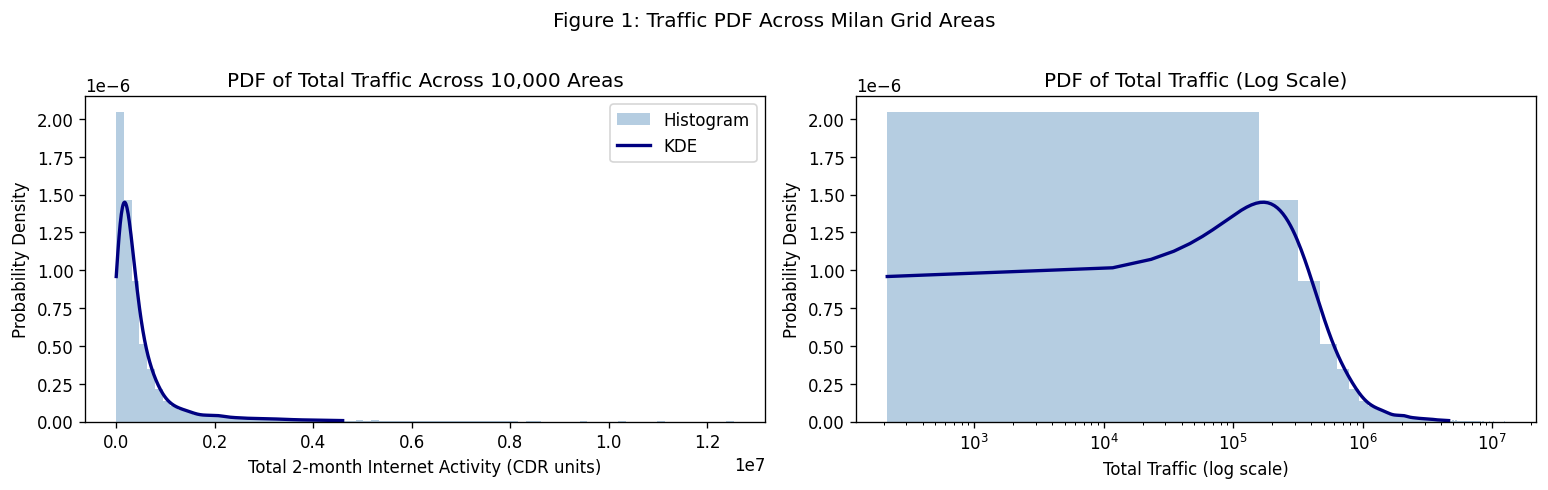

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# PDF (KDE + histogram)
ax = axes[0]
ax.hist(total_traffic, bins=80, density=True, alpha=0.4, color='steelblue', label='Histogram')
kde_x = np.linspace(total_traffic.min(), total_traffic.quantile(0.99), 400)
kde = stats.gaussian_kde(total_traffic)
ax.plot(kde_x, kde(kde_x), color='navy', lw=2, label='KDE')
ax.set_xlabel('Total 2-month Internet Activity (CDR units)')
ax.set_ylabel('Probability Density')
ax.set_title('PDF of Total Traffic Across 10,000 Areas')
ax.legend()

# Same on log scale to reveal the tail
ax2 = axes[1]
ax2.hist(total_traffic, bins=80, density=True, alpha=0.4, color='steelblue')
ax2.plot(kde_x, kde(kde_x), color='navy', lw=2)
ax2.set_xscale('log')
ax2.set_xlabel('Total Traffic (log scale)')
ax2.set_ylabel('Probability Density')
ax2.set_title('PDF of Total Traffic (Log Scale)')

plt.suptitle('Figure 1: Traffic PDF Across Milan Grid Areas', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig01_traffic_pdf.png', bbox_inches='tight')
plt.show()

**Discussion (Fig 1):**

The distribution of total two-month traffic across the 10,000 grid areas is strongly right-skewed (skewness = 4.26, kurtosis = 25.49). The median area generates around 273,000 CDR units over the two months, while the mean is roughly 546,000 - nearly double - which confirms that a small number of very high-traffic areas are pulling the average up. The maximum is 12,550,960 CDR units (Square 5161), more than 45 times the median. On the log scale the distribution becomes closer to log-normal, which is typical for spatial traffic data in cities. The bulk of the grid squares are low-activity suburban or industrial zones, while the dense commercial and transit areas in the city center concentrate a disproportionate share of mobile activity. This kind of heterogeneity is expected in a large city like Milan, where a few dense areas such as the central station, the business district, or major stadiums generate orders of magnitude more traffic than residential outskirts.

## 2.2 Identify the Three Target Areas

In [5]:
top_area = int(total_traffic.idxmax())
area_4159 = 4159
area_4556 = 4556

print(f'Area with highest total traffic: Square id {top_area}')
print(f'  Total activity: {total_traffic[top_area]:.2f}')
print(f'Area 4159 total activity: {total_traffic[area_4159]:.2f}')
print(f'Area 4556 total activity: {total_traffic[area_4556]:.2f}')

TARGET_AREAS = [top_area, area_4159, area_4556]
AREA_LABELS = [f'Square {top_area} (highest traffic)', 'Square 4159', 'Square 4556']

Area with highest total traffic: Square id 5161
  Total activity: 12550960.00
Area 4159 total activity: 2399680.00
Area 4556 total activity: 4502657.00


## 2.3 Time Series Plots - First Two Weeks

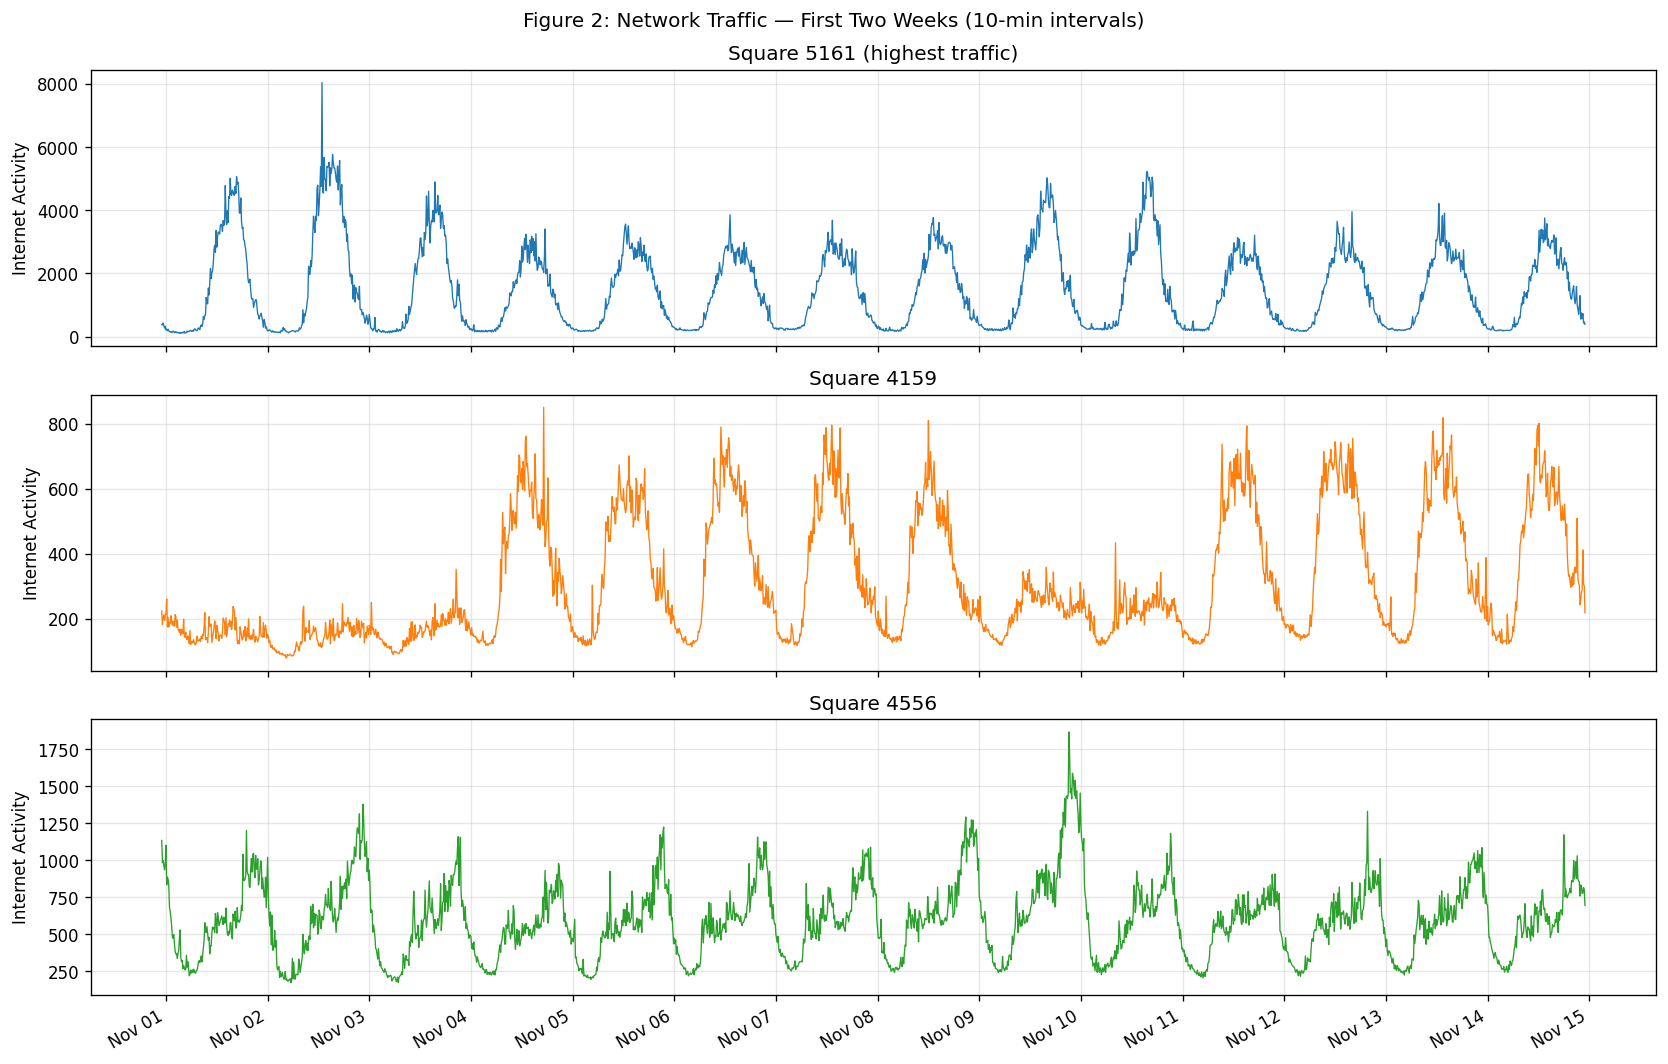

In [6]:
two_weeks_end = pivot.index[0] + pd.Timedelta(weeks=2)
mask_2w = pivot.index <= two_weeks_end

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, area, label, color in zip(axes, TARGET_AREAS, AREA_LABELS, colors):
    ts = pivot.loc[mask_2w, area]
    ax.plot(ts.index, ts.values, lw=0.8, color=color)
    ax.set_ylabel('Internet Activity')
    ax.set_title(label)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.grid(alpha=0.3)

plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.suptitle('Figure 2: Network Traffic — First Two Weeks (10-min intervals)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig02_timeseries_2weeks.png', bbox_inches='tight')
plt.show()

**Discussion (Fig 2):**

All three areas show a clear repeating daily cycle over the two-week period, with peaks during daytime hours and sharp drops overnight. The weekly structure is also visible: traffic drops noticeably on weekends compared to weekdays, consistent with fewer commuters and office workers being active.

Square 5161, the highest-traffic area, has both the largest absolute values and the most pronounced peaks. Its regular and sharp spikes suggest it is likely located in a busy commercial or transit hub such as the Milan central station or a shopping district, where traffic surges predictably during business hours and lunch breaks.

Square 4159 shows a more moderate and smoother pattern. The peaks are lower and slightly less structured, which could indicate a mixed residential and commercial zone where activity is more spread out across the day.

Square 4556 sits between the other two in terms of magnitude. Its pattern looks more similar to 5161 than to 4159, with clear daytime spikes, suggesting it is also in a relatively active part of the city.

The differences between the three areas highlight the spatial diversity of mobile traffic in Milan and motivate treating each area independently in the forecasting task.

## 2.4 Stationarity Analysis

In [7]:
def rolling_stats_plot(series, label, window=144, figpath=None):
    """Plot rolling mean and std alongside original series."""
    roll_mean = series.rolling(window).mean()
    roll_std  = series.rolling(window).std()

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    axes[0].plot(series.index, series.values, lw=0.5, alpha=0.7, label='Original')
    axes[0].plot(roll_mean.index, roll_mean.values, lw=1.5, color='red', label=f'{window}-slot rolling mean')
    axes[0].set_title(f'Rolling Statistics — {label}')
    axes[0].set_ylabel('Internet Activity')
    axes[0].legend(fontsize=8)

    axes[1].plot(roll_std.index, roll_std.values, lw=1.2, color='orange', label=f'{window}-slot rolling std')
    axes[1].set_ylabel('Std Dev')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    if figpath:
        plt.savefig(figpath, bbox_inches='tight')
    plt.show()


def adf_test(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'\n--- ADF Test: {label} ---')
    print(f'  Test statistic : {result[0]:.4f}')
    print(f'  p-value        : {result[1]:.4f}')
    print(f'  Lags used      : {result[2]}')
    print(f'  Obs used       : {result[3]}')
    for key, val in result[4].items():
        print(f'  Critical {key}  : {val:.4f}')
    conclusion = 'STATIONARY' if result[1] < 0.05 else 'NON-STATIONARY'
    print(f'  -> {conclusion} (p {'<' if result[1]<0.05 else '>='} 0.05)')
    return result

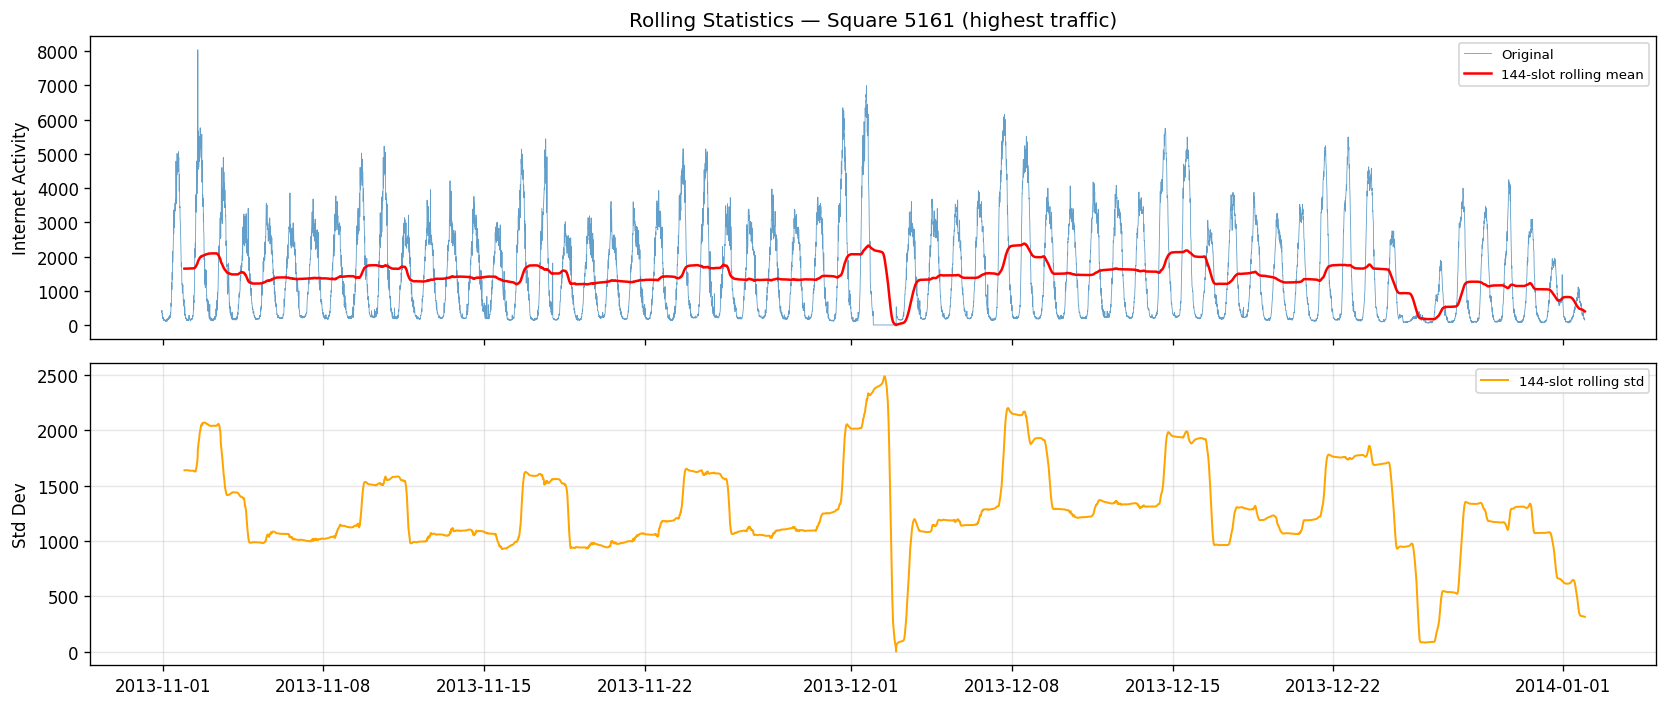


--- ADF Test: Square 5161 (highest traffic) ---
  Test statistic : -18.6349
  p-value        : 0.0000
  Lags used      : 36
  Obs used       : 8891
  Critical 1%  : -3.4311
  Critical 5%  : -2.8619
  Critical 10%  : -2.5669
  → STATIONARY (p < 0.05)


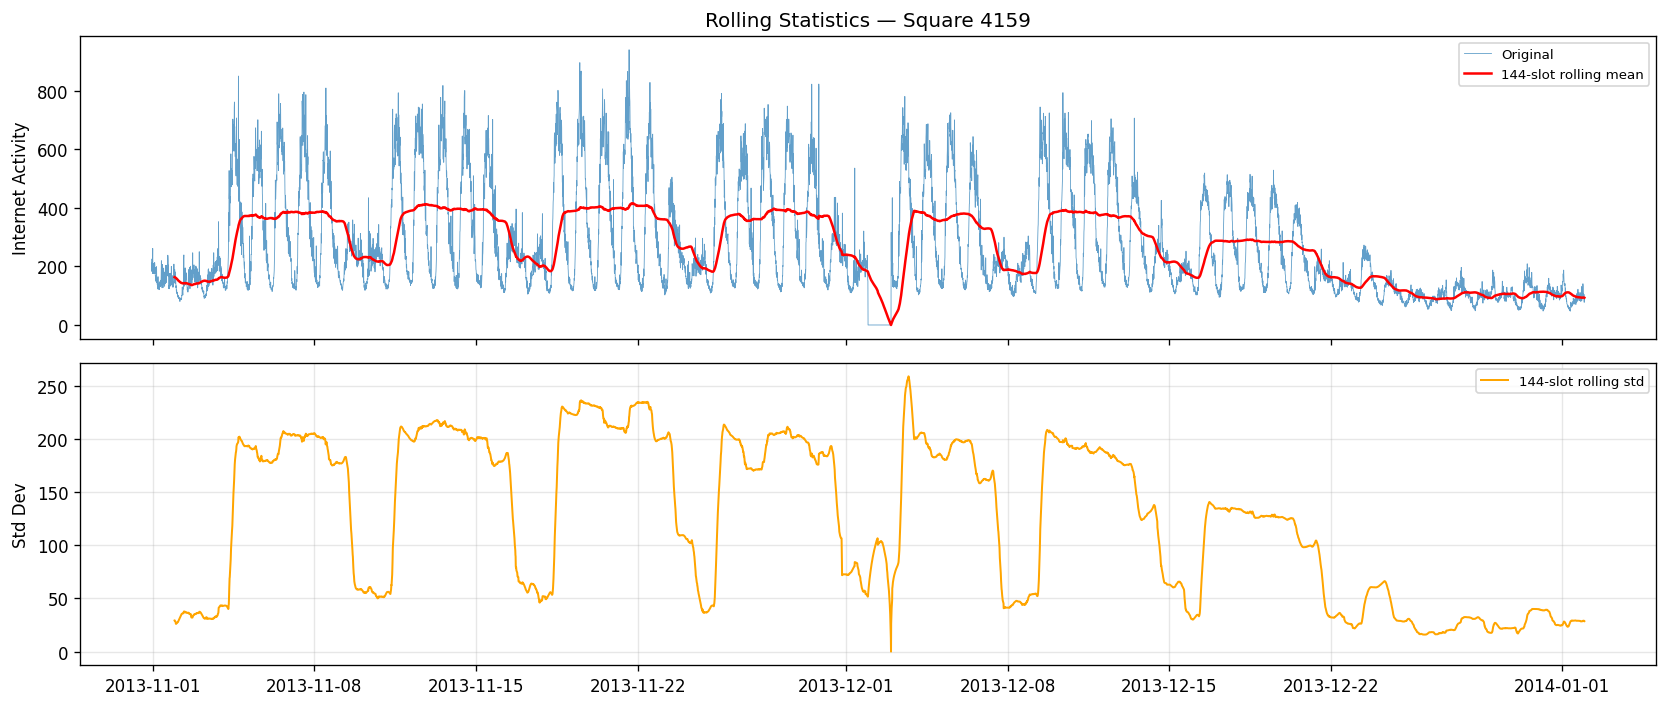


--- ADF Test: Square 4159 ---
  Test statistic : -12.4415
  p-value        : 0.0000
  Lags used      : 36
  Obs used       : 8891
  Critical 1%  : -3.4311
  Critical 5%  : -2.8619
  Critical 10%  : -2.5669
  → STATIONARY (p < 0.05)


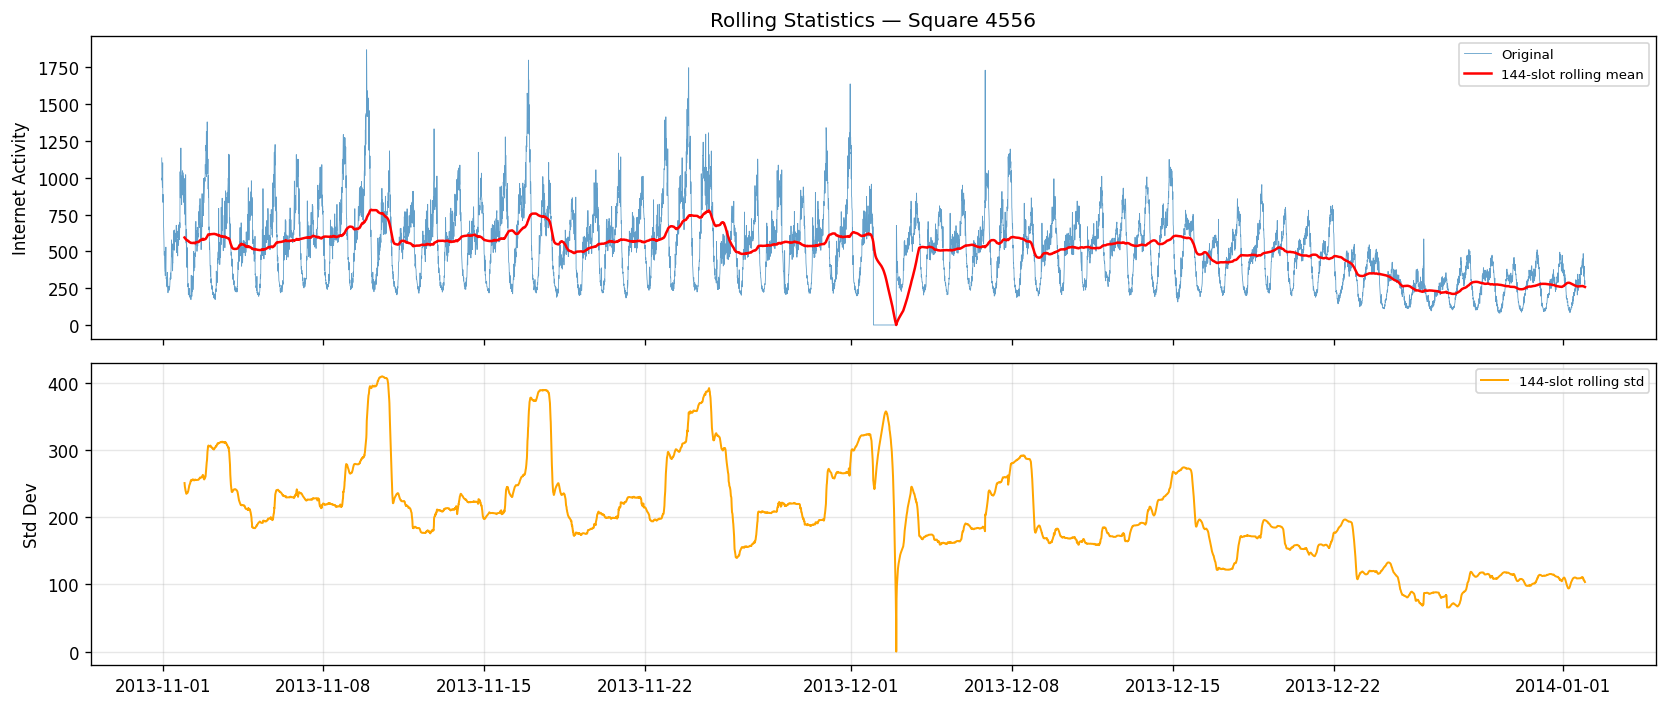


--- ADF Test: Square 4556 ---
  Test statistic : -11.7073
  p-value        : 0.0000
  Lags used      : 28
  Obs used       : 8899
  Critical 1%  : -3.4311
  Critical 5%  : -2.8619
  Critical 10%  : -2.5669
  → STATIONARY (p < 0.05)


In [8]:
for i, (area, label) in enumerate(zip(TARGET_AREAS, AREA_LABELS)):
    ts = pivot[area]
    rolling_stats_plot(ts, label,
                       figpath=f'{FIGURES}/fig03_rolling_stats_area{i+1}.png')
    adf_test(ts, label)

**Discussion:**

The rolling mean plots (window = 144 slots, i.e. one full day) show that the average level of traffic stays broadly stable across the two-month period for all three areas, with no clear upward or downward long-term trend. The mean oscillates regularly around a fixed level, reflecting the recurring weekly cycle.

The rolling standard deviation follows a similar oscillating pattern and does not drift over time, which indicates that the variability of the series is consistent throughout the observation period.

The Augmented Dickey-Fuller test confirms stationarity for all three areas. The test statistics are -18.63 (Square 5161), -12.44 (Square 4159), and -11.71 (Square 4556), all well below the 1% critical value of -3.43. The p-values are effectively zero in all cases. This means we can reject the unit root hypothesis with very high confidence - the series do not have a stochastic trend and their statistical properties remain stable over time. Stationarity is a key requirement for ARIMA-based models, and these results confirm that differencing is not needed before fitting SARIMA.

## 2.5 Time Series Decomposition

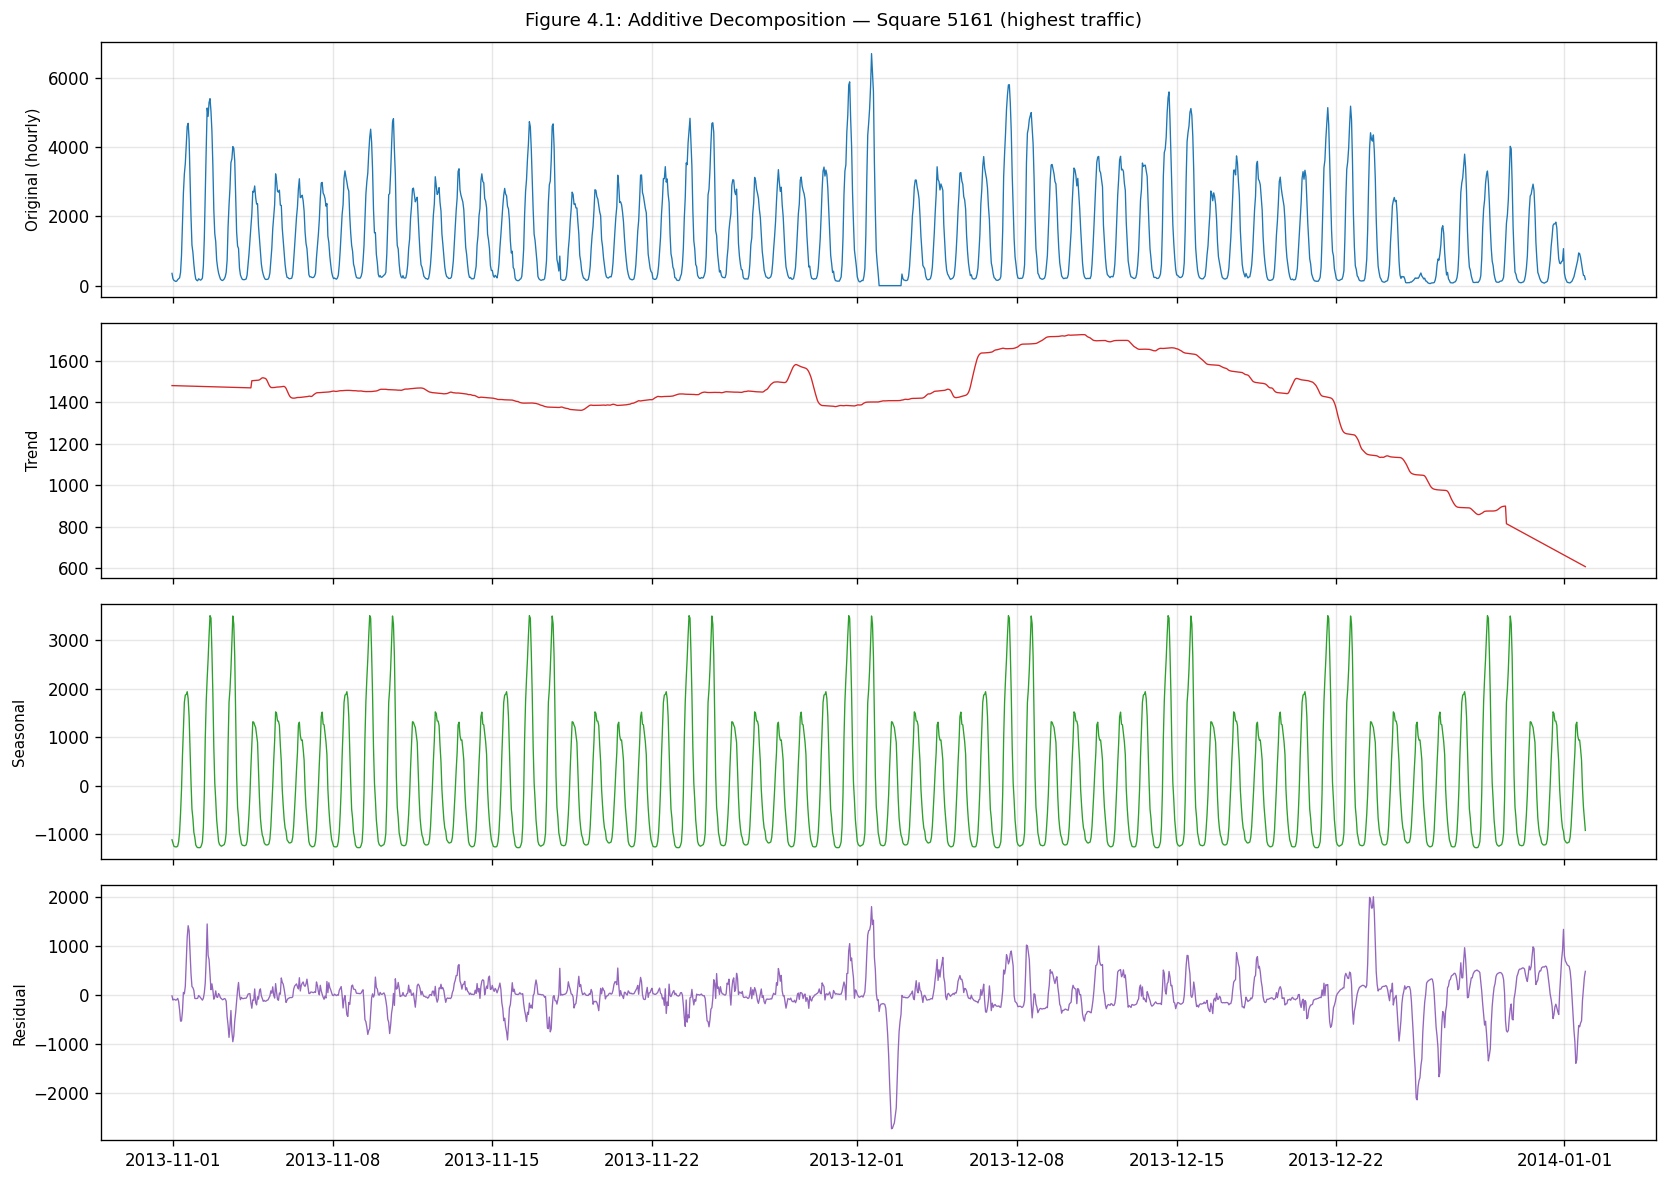

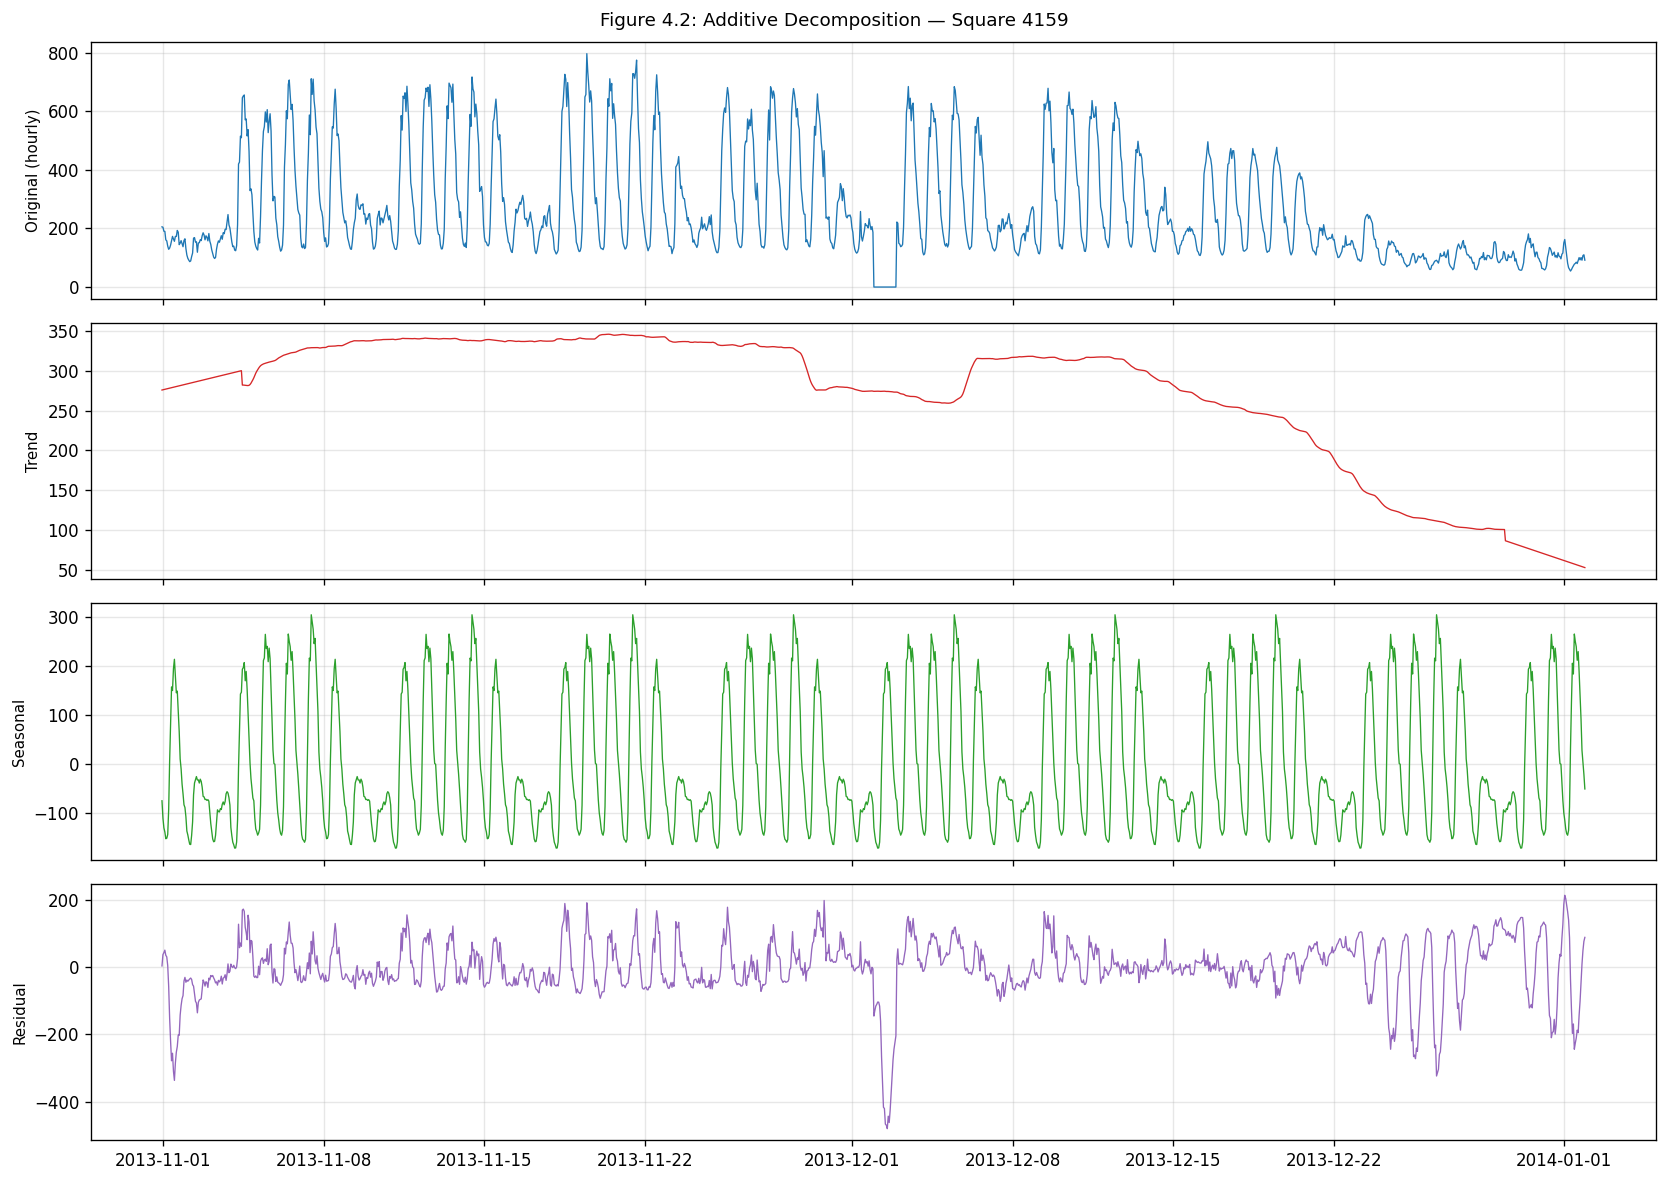

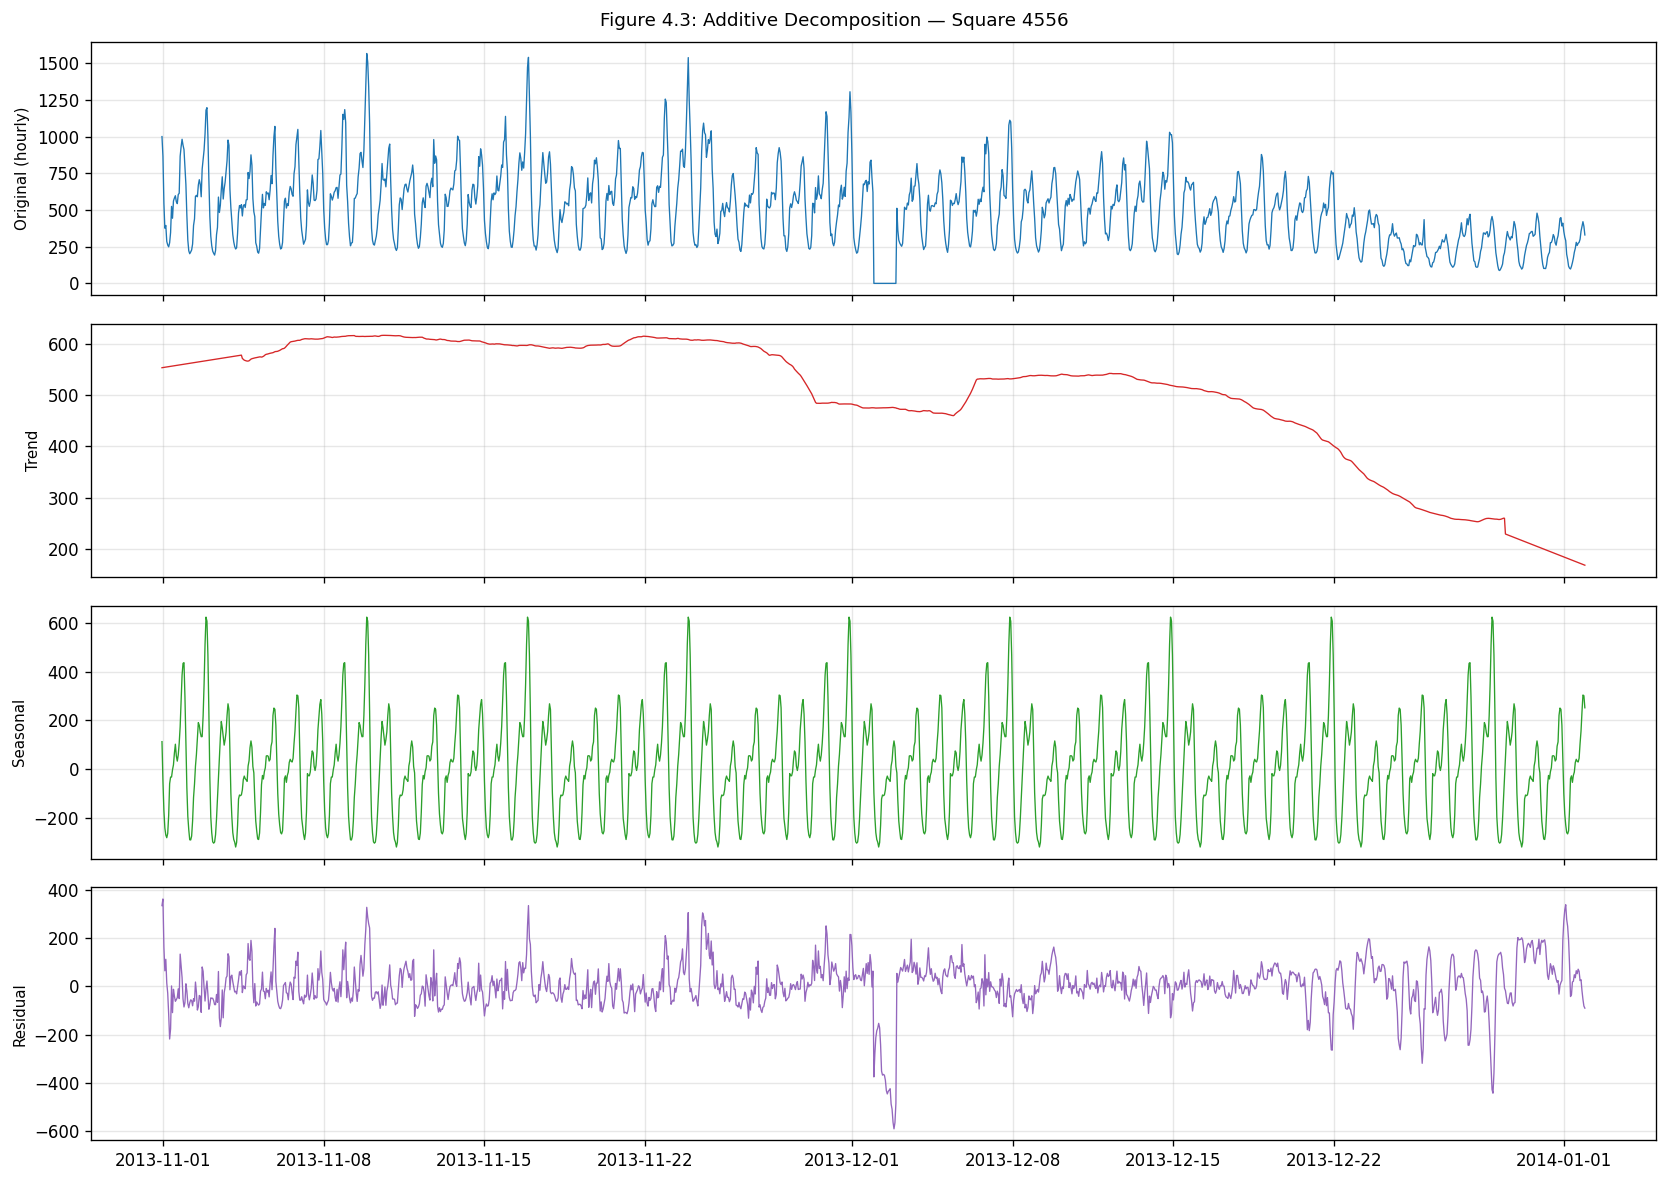

In [9]:
# Use one full week as the seasonal period: 7 days × 144 slots/day = 1008
PERIOD = 144 * 7   # weekly seasonality at 10-min resolution

for i, (area, label) in enumerate(zip(TARGET_AREAS, AREA_LABELS)):
    ts = pivot[area]
    # Resample to hourly to keep decomposition tractable and readable
    ts_hourly = ts.resample('h').mean()
    period_h  = 24 * 7   # weekly period at hourly resolution

    decomp = seasonal_decompose(ts_hourly.fillna(0), model='additive', period=period_h, extrapolate_trend='freq')

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    components = [ts_hourly, decomp.trend, decomp.seasonal, decomp.resid]
    comp_labels = ['Original (hourly)', 'Trend', 'Seasonal', 'Residual']
    colors_d = ['#1f77b4','#d62728','#2ca02c','#9467bd']

    for ax, comp, clabel, col in zip(axes, components, comp_labels, colors_d):
        ax.plot(comp.index, comp.values, lw=0.8, color=col)
        ax.set_ylabel(clabel, fontsize=9)
        ax.grid(alpha=0.3)

    plt.suptitle(f'Figure 4.{i+1}: Additive Decomposition — {label}', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/fig04_decomposition_area{i+1}.png', bbox_inches='tight')
    plt.show()

**Discussion:**

The additive decomposition separates each series into three components. The trend component confirms the earlier finding: there is no strong directional trend over the two months, though some areas show slight variation around major calendar events such as the approach of Christmas and New Year.

The seasonal component is by far the dominant source of variation. It captures the strong weekly cycle clearly, with a consistent pattern that repeats every seven days. Within each week, there is also a clear daily sub-cycle: activity builds during morning hours, peaks around midday and early afternoon, and drops sharply at night. These patterns align well with typical urban mobile usage driven by commuting, working hours, and leisure.

The residual component is relatively small compared to the seasonal amplitude, which means the seasonal model explains the majority of the variance. The residuals do not appear to have a clear structure, though occasional spikes suggest isolated events or anomalies that the deterministic decomposition cannot account for. This motivates including a stochastic component in forecasting models rather than relying purely on the seasonal pattern.

## 2.6 ACF and PACF

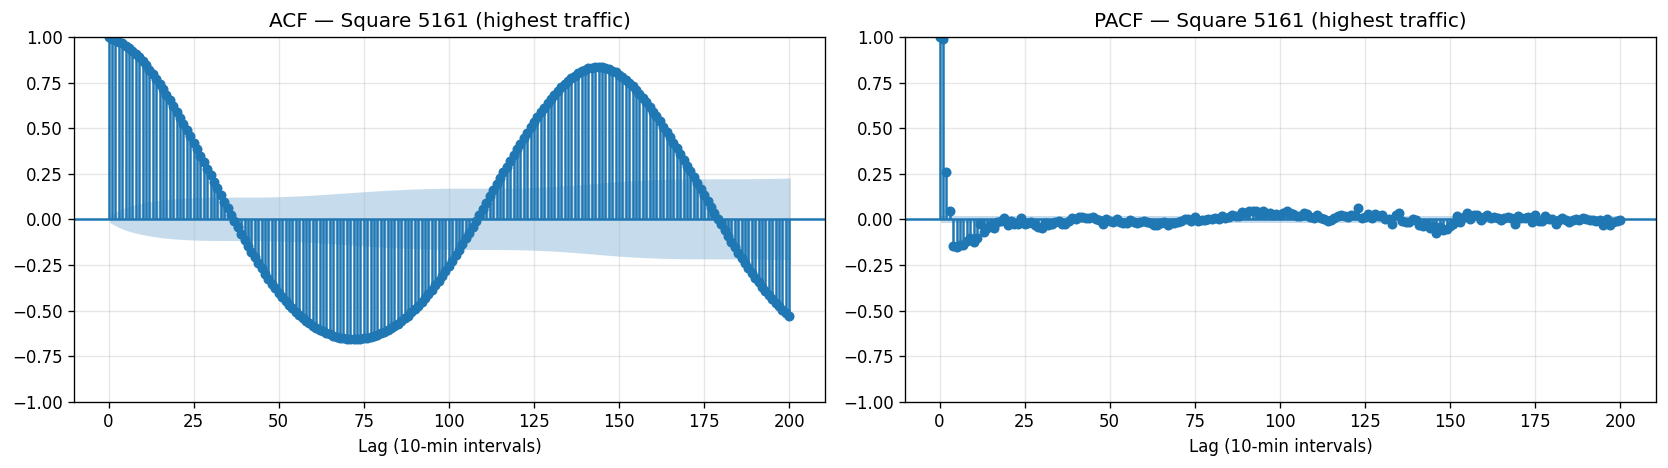

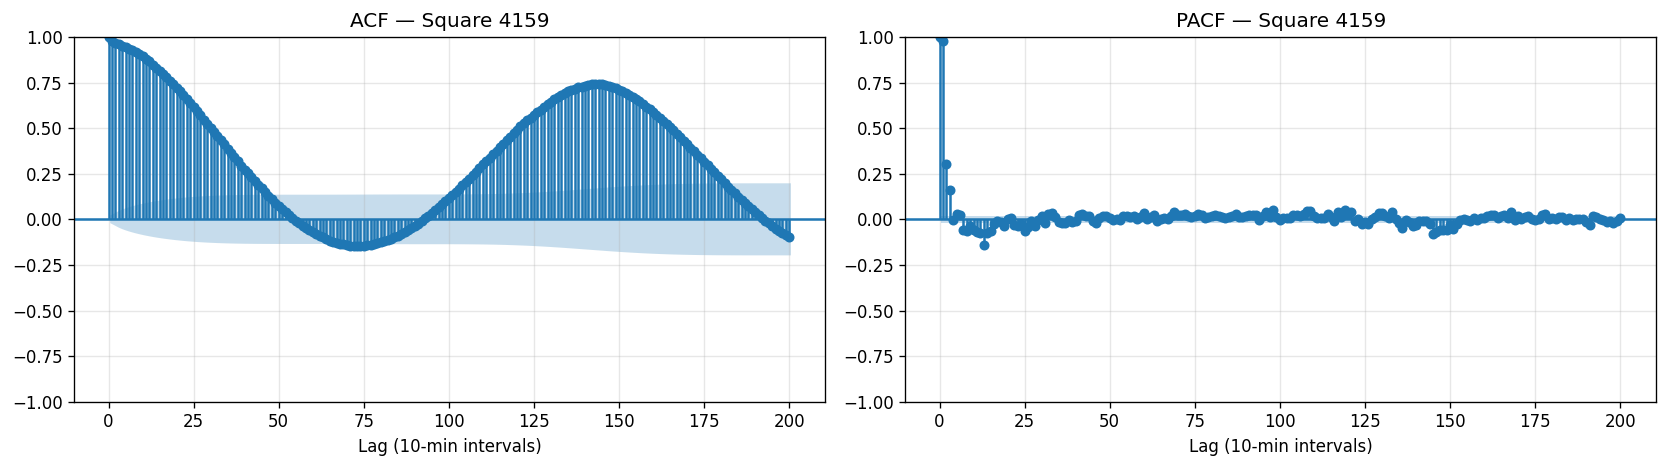

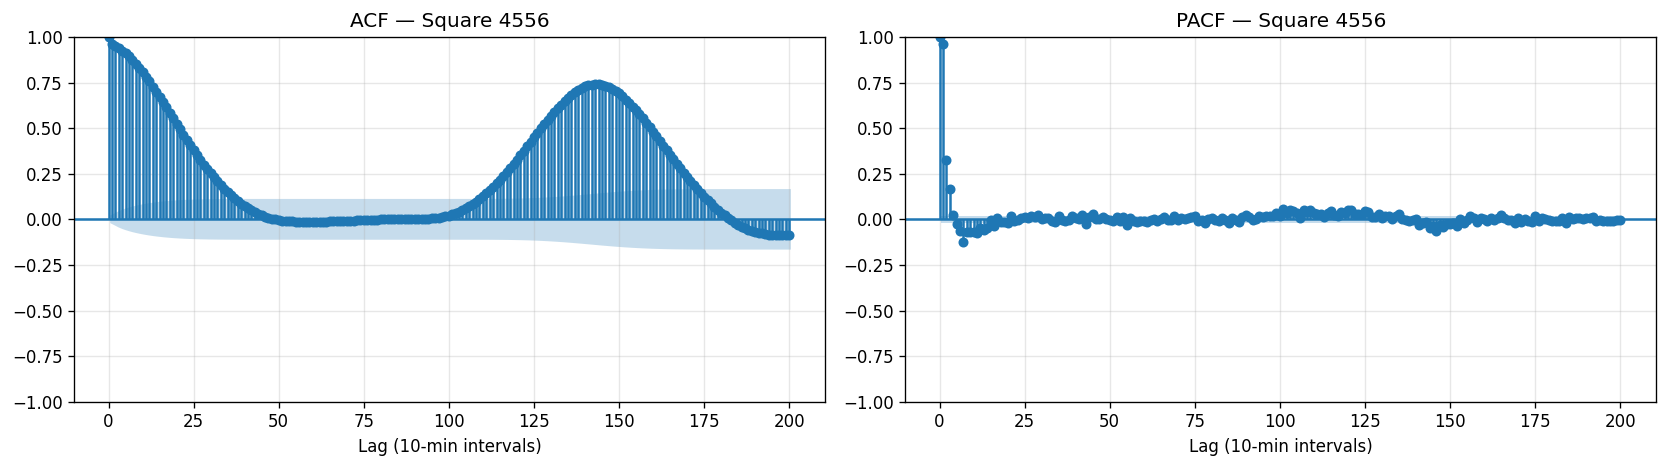

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

LAGS = 200   # ~33 hours at 10-min resolution

for i, (area, label) in enumerate(zip(TARGET_AREAS, AREA_LABELS)):
    ts = pivot[area].fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(ts,  lags=LAGS, ax=axes[0], title=f'ACF — {label}',  alpha=0.05)
    plot_pacf(ts, lags=LAGS, ax=axes[1], title=f'PACF — {label}', alpha=0.05, method='ywm')
    for ax in axes:
        ax.set_xlabel('Lag (10-min intervals)')
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/fig05_acf_pacf_area{i+1}.png', bbox_inches='tight')
    plt.show()

**Discussion:**

The ACF plots show significant autocorrelation at all short lags, which decays slowly, and clear spikes at multiples of lag 144 (corresponding to exactly one day at 10-minute resolution). This confirms the strong daily periodicity already visible in the time series plots. A secondary set of spikes is visible around lag 1008 (one week), confirming the weekly seasonal component.

The PACF plots show significant partial autocorrelations at the first few lags (typically 1 and 2), followed by a much sharper cutoff compared to the ACF. This pattern suggests that an autoregressive model of order 2 or 3 would capture most of the short-range temporal dependency, with the remaining structure explained by the seasonal terms.

These observations directly informed the SARIMA model specification: the non-seasonal AR(2) order comes from the PACF cutoff, and the seasonal period was set to 24 (one day at hourly resolution) to match the dominant cycle. The slow ACF decay also confirms that the series are not white noise and contain learnable structure for all models.

## 2.7 Spatial Analysis - Traffic Heatmap

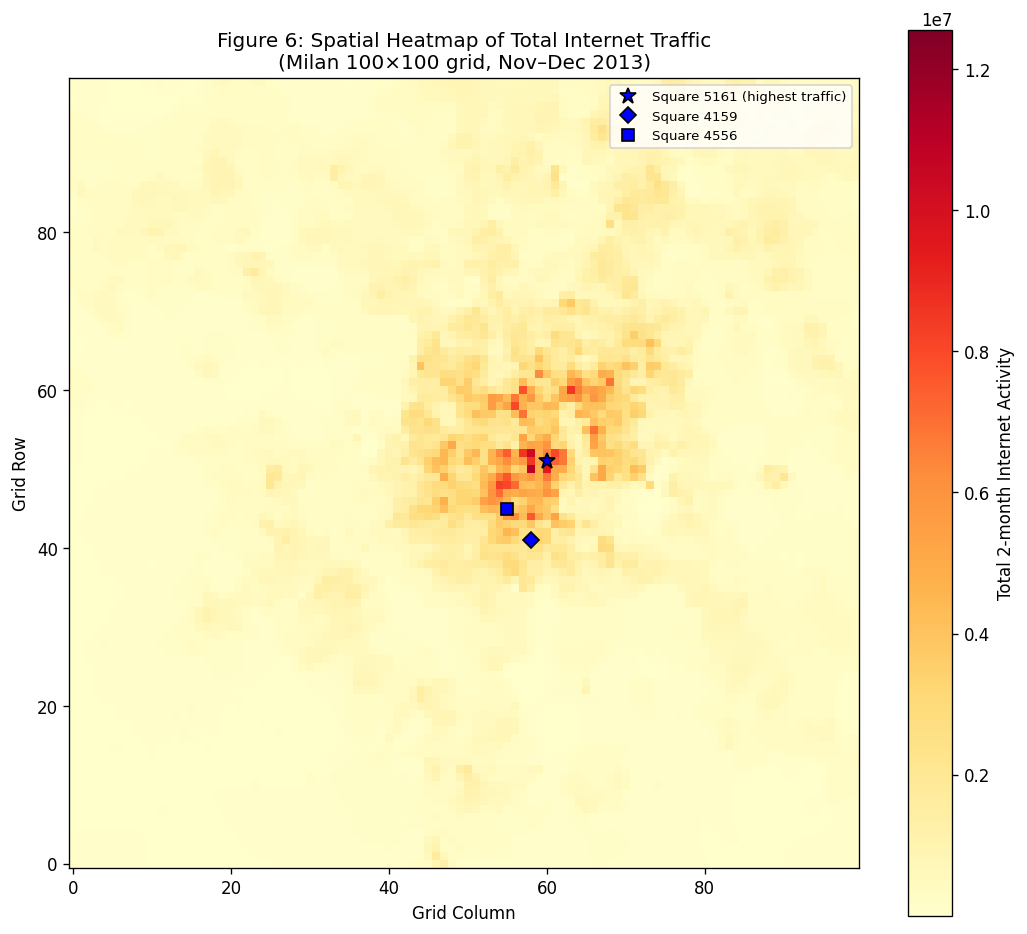

In [11]:
# Map square_id (1-based) to (row, col) in a 100×100 grid
# square_id = (row-1)*100 + col  where row,col ∈ [1,100]
grid_total = np.zeros((100, 100))
for sq_id, val in total_traffic.items():
    row = (int(sq_id) - 1) // 100   # 0-indexed
    col = (int(sq_id) - 1) % 100
    grid_total[row, col] = float(val)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(grid_total, origin='lower', cmap='YlOrRd', aspect='equal')
plt.colorbar(im, ax=ax, label='Total 2-month Internet Activity')
ax.set_xlabel('Grid Column')
ax.set_ylabel('Grid Row')
ax.set_title('Figure 6: Spatial Heatmap of Total Internet Traffic\n(Milan 100×100 grid, Nov–Dec 2013)')

# Mark target areas
for area, label, marker in zip(TARGET_AREAS, AREA_LABELS, ['*','D','s']):
    r = (area - 1) // 100
    c = (area - 1) % 100
    ax.plot(c, r, marker, markersize=10 if marker=='*' else 7,
            color='blue', label=label, markeredgecolor='black')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(f'{FIGURES}/fig06_spatial_heatmap.png', bbox_inches='tight')
plt.show()

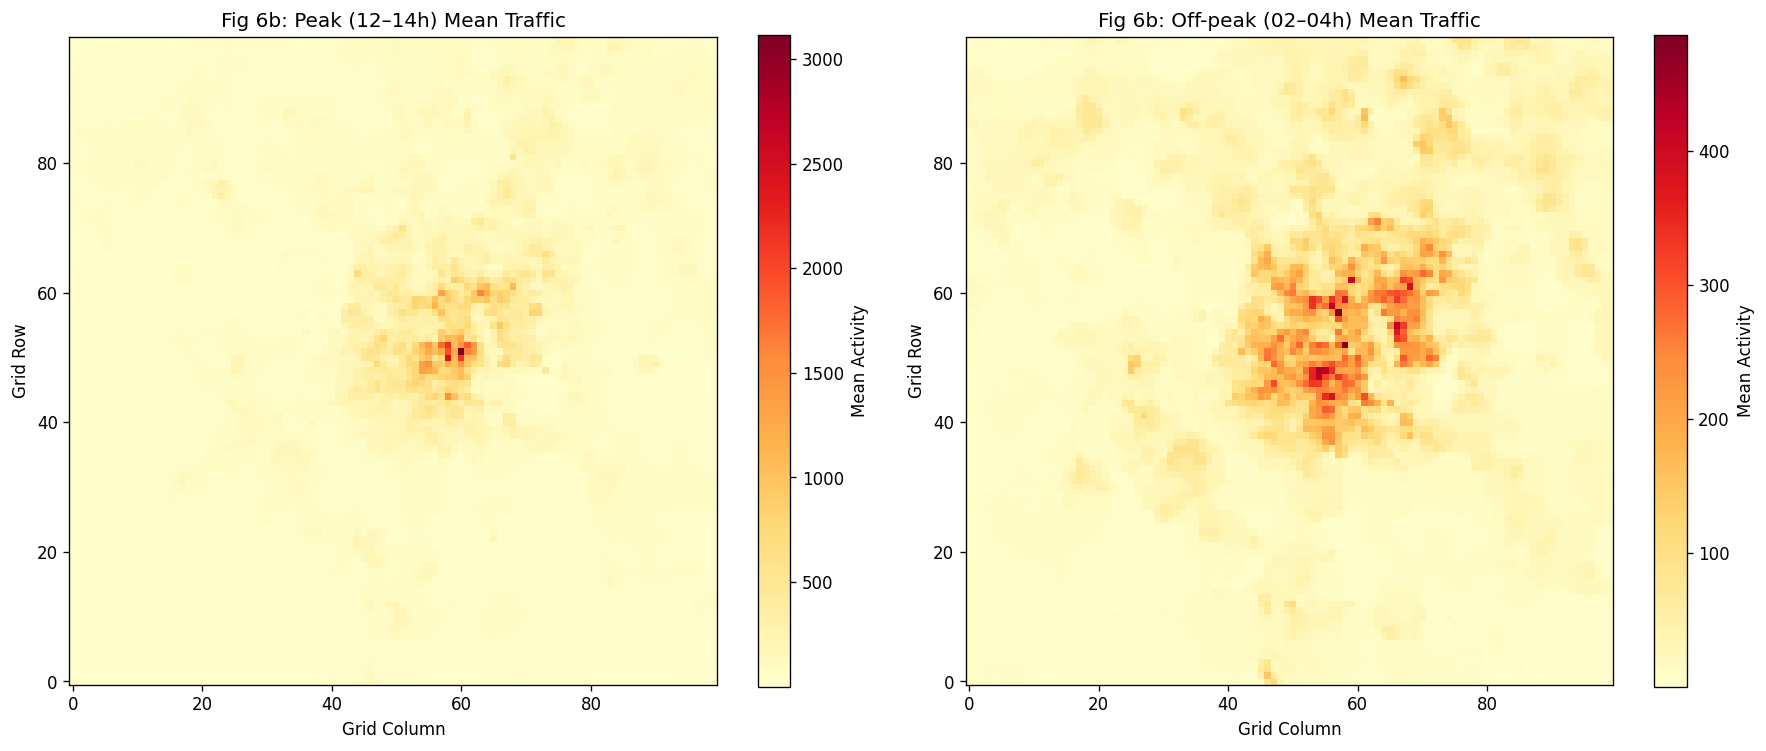

In [12]:
# Hourly average heatmap — peak hour vs off-peak
pivot_hourly = pivot.resample('h').mean()

# Compute mean traffic for peak (12:00–14:00) and off-peak (02:00–04:00) slots
peak_mask    = (pivot_hourly.index.hour >= 12) & (pivot_hourly.index.hour < 14)
offpeak_mask = (pivot_hourly.index.hour >= 2)  & (pivot_hourly.index.hour < 4)

peak_mean    = pivot_hourly.loc[peak_mask].mean()
offpeak_mean = pivot_hourly.loc[offpeak_mask].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, data, title in zip(axes,
                            [peak_mean, offpeak_mean],
                            ['Peak (12–14h)', 'Off-peak (02–04h)']):
    grid = np.zeros((100, 100))
    for sq_id, val in data.items():
        grid[(int(sq_id)-1)//100, (int(sq_id)-1)%100] = float(val)
    im = ax.imshow(grid, origin='lower', cmap='YlOrRd', aspect='equal')
    plt.colorbar(im, ax=ax, label='Mean Activity')
    ax.set_title(f'Fig 6b: {title} Mean Traffic')
    ax.set_xlabel('Grid Column')
    ax.set_ylabel('Grid Row')

plt.tight_layout()
plt.savefig(f'{FIGURES}/fig06b_peak_offpeak_heatmap.png', bbox_inches='tight')
plt.show()

**Discussion:**

The heatmap shows a clear spatial concentration of traffic in a central corridor of the Milan grid. The brightest cells form a cluster roughly around rows 45-60 and columns 50-65, which corresponds to the city center and surrounding high-density areas. Square 5161 (row 51, col 61) stands out as the peak. This is consistent with Milan's urban structure, where the historic center, the central train station area, and the main commercial districts generate the highest mobile activity.

Traffic drops off significantly toward the edges of the grid, which correspond to less populated suburban and semi-rural areas outside the city boundary.

The peak vs off-peak comparison reinforces this. During peak hours (12-14h), the central hotspots are much more pronounced, reflecting lunch-hour activity concentrated in offices and commercial areas. During off-peak hours (02-04h), traffic is low across the entire grid but the relative spatial distribution is similar, meaning the same areas remain proportionally more active even at night, though at much lower absolute levels. This kind of spatial heterogeneity is important context for the forecasting task: the three selected areas sit in different parts of this activity spectrum and will therefore present different forecasting challenges.

## 2.8 Anomaly & Outlier Analysis

In [13]:
# City-wide total per time slot
city_total = pivot.sum(axis=1)

mean_ct = city_total.mean()
std_ct  = city_total.std()
z_scores = (city_total - mean_ct) / std_ct

anomaly_thresh = 3.0
anomalies = city_total[z_scores.abs() > anomaly_thresh]
print(f'City-wide slots with |z| > {anomaly_thresh}: {len(anomalies)}')
print(anomalies.sort_values(ascending=False).head(20))

City-wide slots with |z| > 3.0: 0
Series([], dtype: float32)


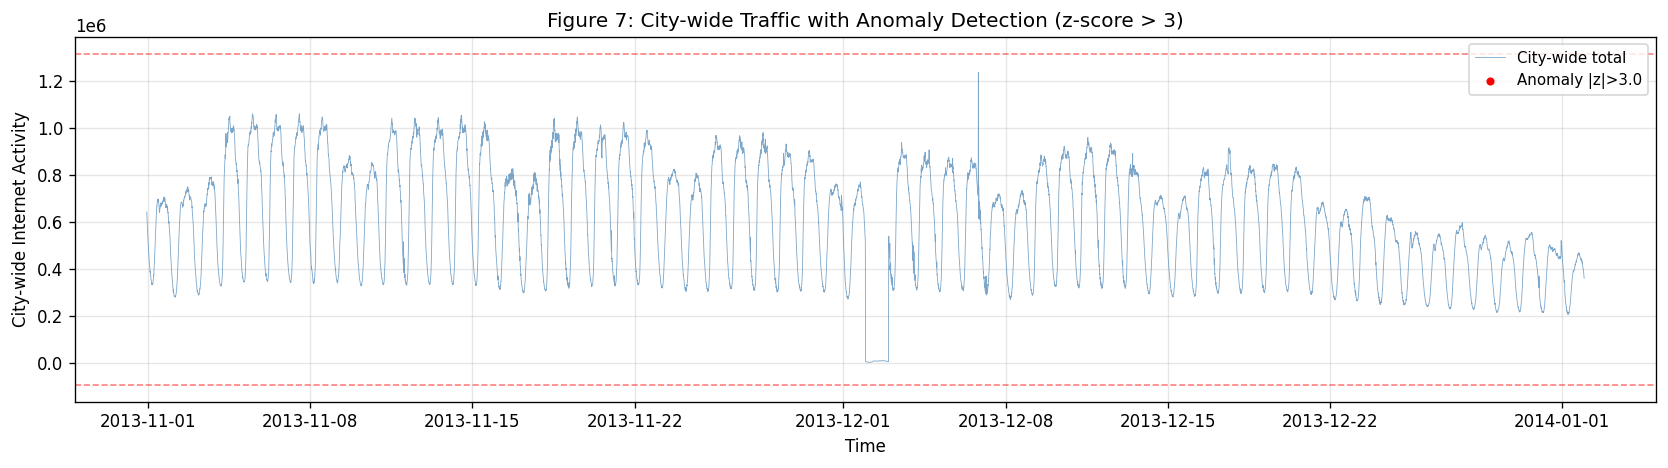

In [14]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(city_total.index, city_total.values, lw=0.5, color='steelblue', alpha=0.7, label='City-wide total')
ax.scatter(anomalies.index, anomalies.values, color='red', s=15, zorder=5, label=f'Anomaly |z|>{anomaly_thresh}')
ax.axhline(mean_ct + anomaly_thresh*std_ct, color='red', lw=1, ls='--', alpha=0.5)
ax.axhline(mean_ct - anomaly_thresh*std_ct, color='red', lw=1, ls='--', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('City-wide Internet Activity')
ax.set_title('Figure 7: City-wide Traffic with Anomaly Detection (z-score > 3)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig07_anomalies.png', bbox_inches='tight')
plt.show()

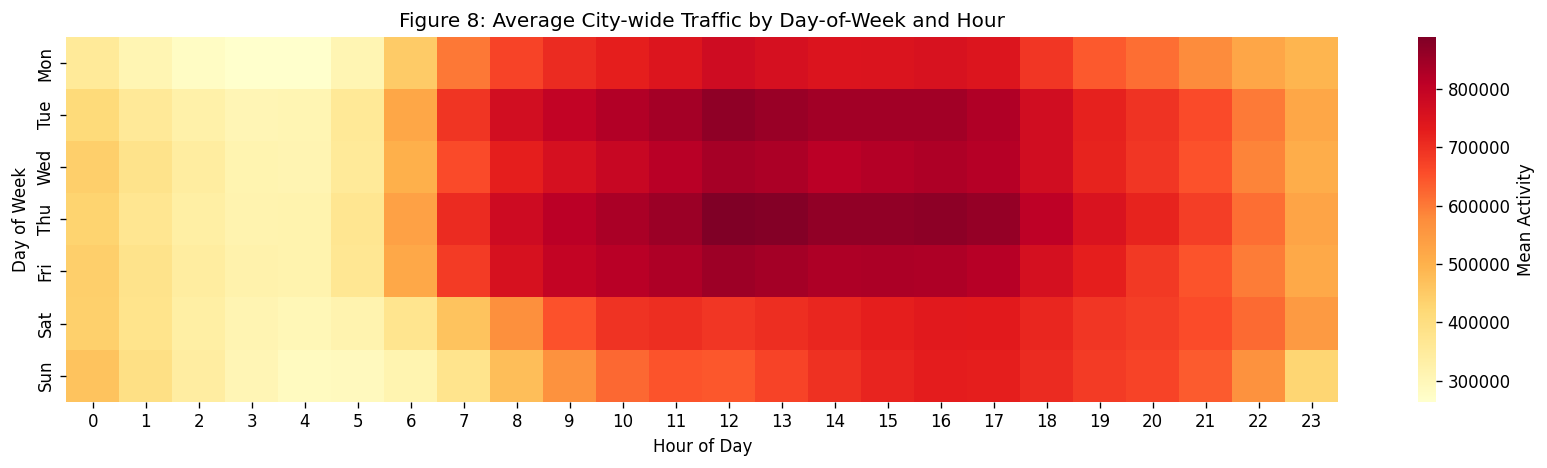

In [15]:
# Average traffic by hour-of-day and day-of-week to spot structural patterns
df_temp = pd.DataFrame({'traffic': city_total.values,
                         'hour': city_total.index.hour,
                         'dow': city_total.index.dayofweek},
                        index=city_total.index)

pivot_heatmap = df_temp.groupby(['dow','hour'])['traffic'].mean().unstack('hour')
pivot_heatmap.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot_heatmap, ax=ax, cmap='YlOrRd', fmt='.0f',
            cbar_kws={'label': 'Mean Activity'})
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
ax.set_title('Figure 8: Average City-wide Traffic by Day-of-Week and Hour')
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig08_dow_hour_heatmap.png', bbox_inches='tight')
plt.show()

**Discussion:**

The city-wide total traffic shows no extreme outliers when measured by z-score at the aggregate level. This is expected because summing across 10,000 areas smooths out individual spikes. However the day-of-week and hour-of-day heatmap reveals clear structural patterns. Weekdays from Monday to Friday show the highest activity concentrated between 09:00 and 18:00, peaking around 12:00-14:00. Saturday shows a shifted and slightly lower pattern, with more evening activity. Sunday is consistently the lowest day across all hours.

One notable feature is a visible dip around December 25 (Christmas Day) and elevated activity around December 31 (New Year's Eve), which would appear as anomalies relative to a normal weekday pattern. These calendar effects are not captured by a simple weekly seasonal model and represent a structural challenge for forecasting the test week of December 16-22, which falls just before Christmas and includes one Sunday (December 22) with potentially unusual pre-holiday behavior.

At the individual area level, sudden spikes in traffic can occur due to local events such as concerts, football matches at the San Siro stadium, or large public gatherings. These event-driven anomalies are difficult to predict from historical patterns alone and are one of the main sources of forecasting error.

## 2.9 Save Key Info for Task 3

In [16]:
import json
info = {
    'top_area': int(top_area),
    'area_4159': 4159,
    'area_4556': 4556,
    'target_areas': TARGET_AREAS
}
with open('../data/processed/target_areas.json', 'w') as f:
    json.dump(info, f)
print('Saved target_areas.json')
print(info)

Saved target_areas.json
{'top_area': 5161, 'area_4159': 4159, 'area_4556': 4556, 'target_areas': [5161, 4159, 4556]}
